# TensorBoard-Plots der MoE-Routing-Loss-r2fix-Reproduktion

Dieses Notebook liest alle TensorBoard-Scalar-Logs aus `moe_runs/randomsearch_new_routingloss/r2fix_reproduce` und erzeugt PNG-Abbildungen fuer den Anhang der Masterarbeit:

- Trainings-Genauigkeit und Validierungsgenauigkeit mit Hard-Routing,
- Nutzung von `$f_{small}$`, `$f_{mid}$` und `$f_{large}$` bei `val_hard`,
- Verlaeufe der `val_topk`-Metriken,
- `val_upper_bound` und `val_budgeted_upper_bound` in einem gemeinsamen Plot.

Die Legenden enthalten Budget-Loss-Weight, Routing-Loss-Weight und Weight Decay. Die Abbildungen werden unter `moe/plots/figures_routingloss_r2fix_reproduce` gespeichert.

In [1]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Matplotlib-Stil in Anlehnung an die bestehenden Plots in single_pulse_classifier_training/plot.
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.prop_cycle": plt.cycler(
        "color",
        [
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        ],
    ),
})

In [2]:
RUN_DIR_NAME = "randomsearch_new_routingloss/r2fix_reproduce"
OUT_DIR_NAME = "figures_routingloss_r2fix_reproduce"


def finde_moe_root() -> Path:
    # Findet den moe-Ordner, egal ob das Notebook aus dem Repo-Root oder aus moe/plots gestartet wird.
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        for kandidat in (base, base / "moe", base / "single_pulse_classifier_training" / "moe"):
            if (kandidat / "moe_runs" / RUN_DIR_NAME).exists():
                return kandidat
    raise FileNotFoundError(f"moe_runs/{RUN_DIR_NAME} konnte vom aktuellen Arbeitsverzeichnis aus nicht gefunden werden.")


MOE_ROOT = finde_moe_root()
RUN_ROOT = MOE_ROOT / "moe_runs" / RUN_DIR_NAME
OUT_DIR = MOE_ROOT / "plots" / OUT_DIR_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

MOE_ROOT, RUN_ROOT, OUT_DIR

(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/randomsearch_new_routingloss/r2fix_reproduce'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_routingloss_r2fix_reproduce'))

In [3]:
def dekodiere_float_token(token: str) -> str:
    return token.replace("p", ".").replace("em", "e-")


def format_float(value) -> str:
    if value is None:
        return "?"
    try:
        return f"{float(value):g}"
    except (TypeError, ValueError):
        return str(value)


def ergänze_config_werte(meta: dict, run_dir: Path) -> dict:
    config_path = run_dir / "run_config.json"
    if not config_path.exists():
        return meta
    try:
        config = json.loads(config_path.read_text())
    except Exception:
        return meta

    training = config.get("training", {})
    if "weight_decay" not in meta and "weight_decay" in training:
        meta["weight_decay"] = format_float(training["weight_decay"])
    if "expert_lr" not in meta and "expert_learning_rate" in training:
        meta["expert_lr"] = format_float(training["expert_learning_rate"])
    if "budget" not in meta and "budget_loss_weight" in training:
        meta["budget"] = int(float(training["budget_loss_weight"]))
    if "routing" not in meta and "routing_loss_weight" in training:
        meta["routing"] = float(training["routing_loss_weight"])
    if "seed" not in meta and "seed" in config:
        meta["seed"] = int(config["seed"])
    return meta


def setze_label(meta: dict) -> dict:
    trial = meta.get("trial")
    seed = meta.get("seed", "?")
    wd = meta.get("weight_decay", "?")
    lr = meta.get("expert_lr", "?")
    prefix = f"Trial {trial}, Seed {seed}" if trial is not None else f"Seed {seed}"
    freeze = ", freeze" if "freeze_upper_bound_patience" in meta else ""
    meta["base_label"] = f"{prefix}, lr={lr}, wd={wd}{freeze}"
    meta["label"] = meta["base_label"]
    return meta


def parse_run_name(run_name: str) -> dict:
    muster = {
        "trial": r"trial(\d+)",
        "seed": r"seed(\d+)",
        "expert_lr": r"expertlr([^_]+)",
        "rejector_lr": r"rejectorlr([^_]+)",
        "weight_decay": r"wd([^_]+)",
        "temperatur": r"temp([^_]+)",
        "budget": r"budget(\d+)",
        "routing": r"routing(\d+(?:_\d+)?)",
        "freeze_upper_bound_patience": r"freezeupperboundpat(\d+)",
        "aux_warmup": r"auxwarmup(\d+)",
    }
    meta = {"run": run_name}
    for key, pattern in muster.items():
        match = re.search(pattern, run_name)
        if not match:
            continue
        wert = match.group(1)
        if key in {"trial", "seed", "budget", "freeze_upper_bound_patience", "aux_warmup"}:
            meta[key] = int(wert)
        elif key == "routing":
            meta[key] = float(wert.replace("_", "."))
        else:
            meta[key] = dekodiere_float_token(wert)
    return setze_label(meta)


def load_tensorboard_scalars(run_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    zeilen = []
    run_zeilen = []

    for run_dir in sorted(p for p in run_root.iterdir() if p.is_dir()):
        tb_dir = run_dir / "tensorboard"
        meta = parse_run_name(run_dir.name)
        meta = setze_label(ergänze_config_werte(meta, run_dir))
        meta.update({"path": str(run_dir), "tensorboard_path": str(tb_dir)})

        if not tb_dir.exists():
            meta.update({"status": "TensorBoard-Ordner fehlt", "n_tags": 0, "n_points": 0})
            run_zeilen.append(meta)
            continue

        accumulator = EventAccumulator(str(tb_dir), size_guidance={"scalars": 0})
        try:
            accumulator.Reload()
        except Exception as exc:
            meta.update({"status": f"Lesefehler: {exc}", "n_tags": 0, "n_points": 0})
            run_zeilen.append(meta)
            continue

        tags = accumulator.Tags().get("scalars", [])
        n_points = 0
        for tag in tags:
            events = accumulator.Scalars(tag)
            n_points += len(events)
            for event in events:
                zeilen.append({
                    **meta,
                    "tag": tag,
                    "epoche": event.step,
                    "wall_time": event.wall_time,
                    "wert": float(event.value),
                })

        meta.update({"status": "ok" if tags else "keine Scalar-Tags", "n_tags": len(tags), "n_points": n_points})
        run_zeilen.append(meta)

    scalars = pd.DataFrame(zeilen)
    runs = pd.DataFrame(run_zeilen).sort_values(
        ["status", "seed", "routing", "weight_decay", "run"],
        na_position="last",
    )
    return scalars, runs


scalars, runs = load_tensorboard_scalars(RUN_ROOT)
print(f"Geladen: {len(scalars):,} Scalar-Punkte aus {runs.query('n_points > 0').shape[0]} Durchläufen.")
display(runs[["label", "status", "n_tags", "n_points", "run"]])

Geladen: 72,100 Scalar-Punkte aus 8 Durchläufen.


,label,status,n_tags,n_points,run
3,"Seed 42, lr=8.2848e-05, wd=1e-05",ok,99,11900,seed42_routing1_5
0,"Trial 0, Seed 42, lr=8.285e-05, wd=1e-05",ok,99,10000,joint_moe_worker0_trial0_seed42_expertlr8p285e...
4,"Seed 42, lr=8.2848e-05, wd=1e-05",ok,99,9600,seed42_routing2_5
5,"Seed 43, lr=8.2848e-05, wd=1e-05",ok,99,7000,seed43_routing2
1,"Trial 1, Seed 43, lr=1.305e-06, wd=1e-06",ok,99,5700,joint_moe_worker0_trial1_seed43_expertlr1p305e...
2,"Trial 2, Seed 44, lr=1.681e-05, wd=0",ok,99,3900,joint_moe_worker0_trial2_seed44_expertlr1p681e...
6,"Seed 44, lr=8.2848e-05, wd=1e-05",ok,99,12000,seed44_routing2
7,"Seed 45, lr=8.2848e-05, wd=1e-05",ok,99,12000,seed45_routing2


In [4]:
ERWARTETE_TAGS = [
    "train/accuracy",
    "val_hard/accuracy",
    "val_hard/usage_small",
    "val_hard/usage_mid",
    "val_hard/usage_large",
    "val_topk/accuracy",
    "val_upper_bound",
    "val_budgeted_upper_bound",
]

verfuegbare_tags = sorted(scalars["tag"].unique()) if not scalars.empty else []
fehlende_tags = [tag for tag in ERWARTETE_TAGS if tag not in verfuegbare_tags]
if fehlende_tags:
    warnings.warn("Folgende erwartete TensorBoard-Tags fehlen: " + ", ".join(fehlende_tags))

print("Verfuegbare Scalar-Tags:")
for tag in verfuegbare_tags:
    print(" -", tag)

Verfuegbare Scalar-Tags:
 - learning_rate/group_0
 - learning_rate/group_1
 - train/accuracy
 - train/budget
 - train/budget_loss_weight
 - train/budget_weight
 - train/ensemble
 - train/expert_aux
 - train/expert_aux_loss_weight
 - train/expert_aux_weight
 - train/expert_large
 - train/expert_mid
 - train/expert_small
 - train/experts_frozen
 - train/only_aux_warmup
 - train/routed
 - train/routing
 - train/routing_loss_weight
 - train/routing_r1
 - train/routing_r2
 - train/routing_r2_benefit_gap
 - train/routing_r2_score_gap
 - train/routing_weight
 - train/soft_usage_large
 - train/soft_usage_mid
 - train/soft_usage_small
 - train/topk_noise_std
 - train/total
 - train/usage_large
 - train/usage_mid
 - train/usage_small
 - val_budgeted_upper_bound
 - val_expert/aux
 - val_expert/aux_weight
 - val_expert/large
 - val_expert/large_accuracy
 - val_expert/large_loss
 - val_expert/mid
 - val_expert/mid_accuracy
 - val_expert/mid_loss
 - val_expert/small
 - val_expert/small_accuracy
 - v

In [5]:
gueltige_runs = runs.loc[runs["n_points"] > 0].copy()
gueltige_runs = gueltige_runs.sort_values(["seed", "routing", "weight_decay", "run"], na_position="last")
run_order = gueltige_runs["run"].tolist()


def scalar_weight_label(tag: str, prefix: str) -> dict[str, str]:
    frame = scalars.loc[scalars["tag"] == tag, ["run", "wert"]]
    labels = {}
    for run, values in frame.groupby("run")["wert"]:
        unique_values = sorted({float(value) for value in values})
        if len(unique_values) == 1:
            labels[run] = f"{prefix}={unique_values[0]:g}"
        else:
            labels[run] = f"{prefix}=" + "→".join(f"{value:g}" for value in unique_values)
    return labels

budget_weight_labels = scalar_weight_label("train/budget_loss_weight", "w_budget")
routing_weight_labels = scalar_weight_label("train/routing_loss_weight", "w_routing")

gueltige_runs["label"] = gueltige_runs.apply(
    lambda row: (
        f"{row['base_label']}, "
        f"{budget_weight_labels.get(row['run'], 'w_budget=?')}, "
        f"{routing_weight_labels.get(row['run'], 'w_routing=?')}"
    ),
    axis=1,
)
label_by_run = dict(zip(gueltige_runs["run"], gueltige_runs["label"]))

farben = plt.colormaps["tab20"].resampled(max(len(run_order), 1))
color_by_run = {run: farben(i) for i, run in enumerate(run_order)}

USAGE_TAGS = {
    "val_hard/usage_small": r"$f_{small}$",
    "val_hard/usage_mid": r"$f_{mid}$",
    "val_hard/usage_large": r"$f_{large}$",
}

TOPK_TAG_LABELS = {
    "val_topk/accuracy": "Genauigkeit",
    "val_topk/total": "Gesamt-Loss",
    "val_topk/ensemble": "Ensemble-Loss",
    "val_topk/expert_small": r"Loss $f_{small}$",
    "val_topk/expert_mid": r"Loss $f_{mid}$",
    "val_topk/expert_large": r"Loss $f_{large}$",
    "val_topk/usage_small": r"Nutzung $f_{small}$",
    "val_topk/usage_mid": r"Nutzung $f_{mid}$",
    "val_topk/usage_large": r"Nutzung $f_{large}$",
}


def tag_frame(tag: str) -> pd.DataFrame:
    frame = scalars.loc[scalars["tag"] == tag, ["run", "label", "epoche", "wert"]].copy()
    return frame.sort_values(["run", "epoche"])


def ist_anteil(frame: pd.DataFrame) -> bool:
    if frame.empty:
        return False
    return frame["wert"].dropna().between(-0.02, 1.02).all()


def style_axis(ax, ylabel=None, ylim=None):
    ax.set_xlabel("Epoche")
    if ylabel:
        ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=":", alpha=0.7, color="gray")


def speichere_abbildung(fig, dateiname: str):
    path = OUT_DIR / f"{dateiname}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Gespeichert: {path.relative_to(MOE_ROOT)}")


def durchlauf_legende(ax, title="Durchlauf"):
    handles = [
        Line2D([0], [0], color=color_by_run[run], linewidth=2.0, label=label_by_run[run])
        for run in run_order
    ]
    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title=title,
        fontsize=8,
        framealpha=0.95,
    )


def beste_runs_nach_tag(tag: str) -> list[str]:
    frame = tag_frame(tag)
    if frame.empty:
        return run_order
    ranking = (
        frame.groupby("run", as_index=False)["wert"]
        .max()
        .sort_values("wert", ascending=False)
    )
    return ranking["run"].tolist()

## Trainings-Genauigkeit und Validierungsgenauigkeit mit Hard-Routing

Gespeichert: plots/figures_routingloss_r2fix_reproduce/routingloss_r2fix_reproduce_train_val_hard_accuracy.png


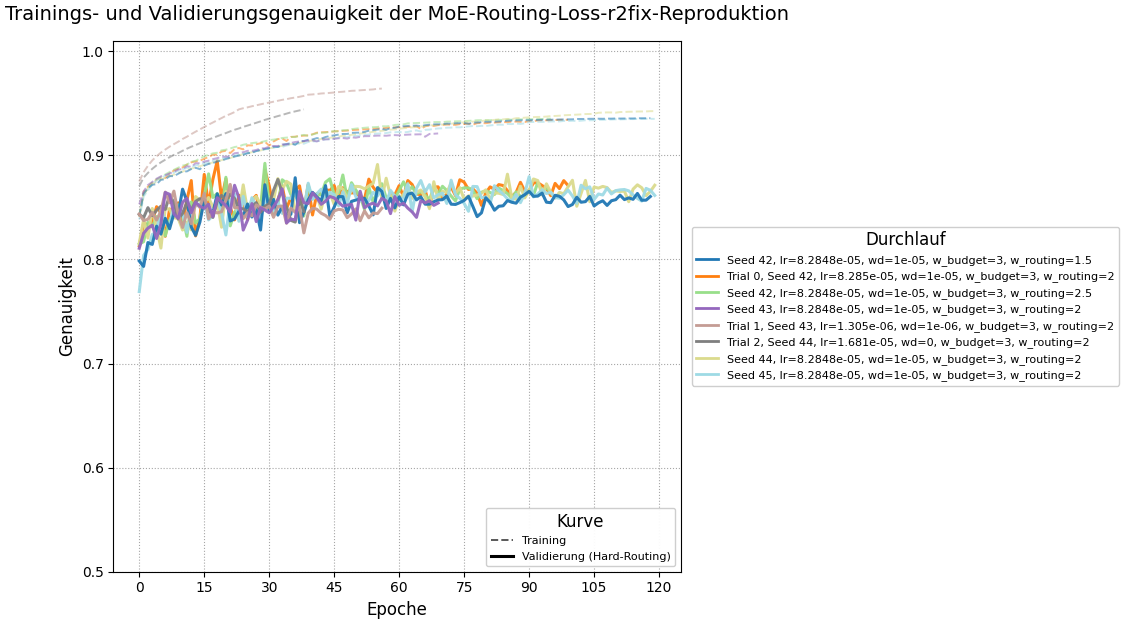

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.5))
run_order_accuracy = beste_runs_nach_tag("val_hard/accuracy")

for run in run_order_accuracy:
    train_frame = tag_frame("train/accuracy").loc[lambda df: df["run"] == run]
    val_frame = tag_frame("val_hard/accuracy").loc[lambda df: df["run"] == run]
    color = color_by_run[run]

    if not train_frame.empty:
        ax.plot(
            train_frame["epoche"],
            train_frame["wert"],
            color=color,
            linestyle="--",
            linewidth=1.4,
            alpha=0.55,
        )
    if not val_frame.empty:
        ax.plot(
            val_frame["epoche"],
            val_frame["wert"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )

style_axis(ax, ylabel="Genauigkeit", ylim=(0.5, 1.01))
ax.set_title("Trainings- und Validierungsgenauigkeit der MoE-Routing-Loss-r2fix-Reproduktion", pad=15)

style_handles = [
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.4, alpha=0.65, label="Training"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=2.2, label="Validierung (Hard-Routing)"),
]
first_legend = ax.legend(handles=style_handles, loc="lower right", title="Kurve", framealpha=0.95)
ax.add_artist(first_legend)
durchlauf_legende(ax)

fig.tight_layout()
speichere_abbildung(fig, "routingloss_r2fix_reproduce_train_val_hard_accuracy")
plt.show()

## Nutzung der Klassifikatoren bei Hard-Routing

Gespeichert: plots/figures_routingloss_r2fix_reproduce/routingloss_r2fix_reproduce_val_hard_classifier_usage.png


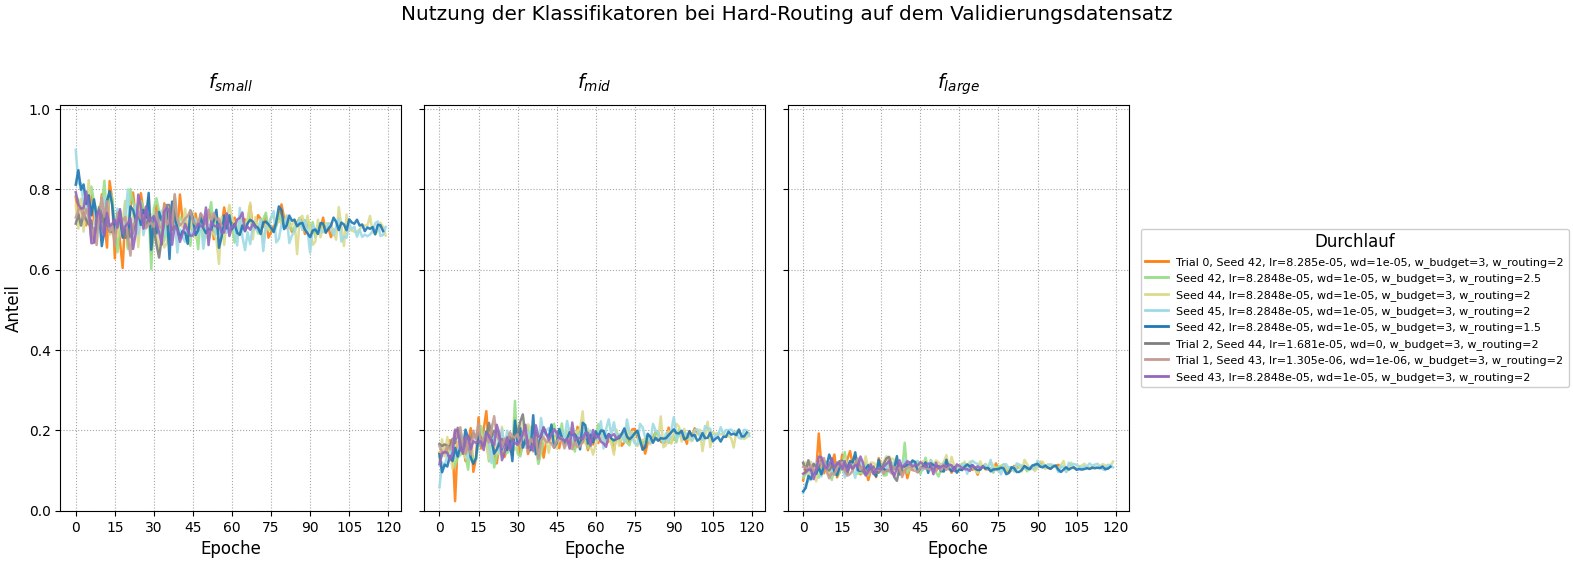

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6), sharex=True, sharey=True)
run_order_usage = beste_runs_nach_tag("val_hard/accuracy")

for ax, (tag, title) in zip(axes, USAGE_TAGS.items()):
    frame = tag_frame(tag)
    for run in run_order_usage:
        run_frame = frame.loc[frame["run"] == run]
        if run_frame.empty:
            continue
        ax.plot(
            run_frame["epoche"],
            run_frame["wert"],
            color=color_by_run[run],
            linewidth=1.8,
            alpha=0.9,
        )
    ax.set_title(title, pad=12)
    style_axis(ax, ylabel="Anteil" if ax is axes[0] else None, ylim=(0.0, 1.01))

handles = [
    Line2D([0], [0], color=color_by_run[run], linewidth=2.0, label=label_by_run[run])
    for run in run_order_usage
]
axes[-1].legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Durchlauf",
    fontsize=8,
    framealpha=0.95,
)
fig.suptitle("Nutzung der Klassifikatoren bei Hard-Routing auf dem Validierungsdatensatz", y=1.02)
fig.tight_layout()
speichere_abbildung(fig, "routingloss_r2fix_reproduce_val_hard_classifier_usage")
plt.show()

## Validierungsverläufe für Top-k-Routing

Gespeichert: plots/figures_routingloss_r2fix_reproduce/routingloss_r2fix_reproduce_val_topk_accuracy.png


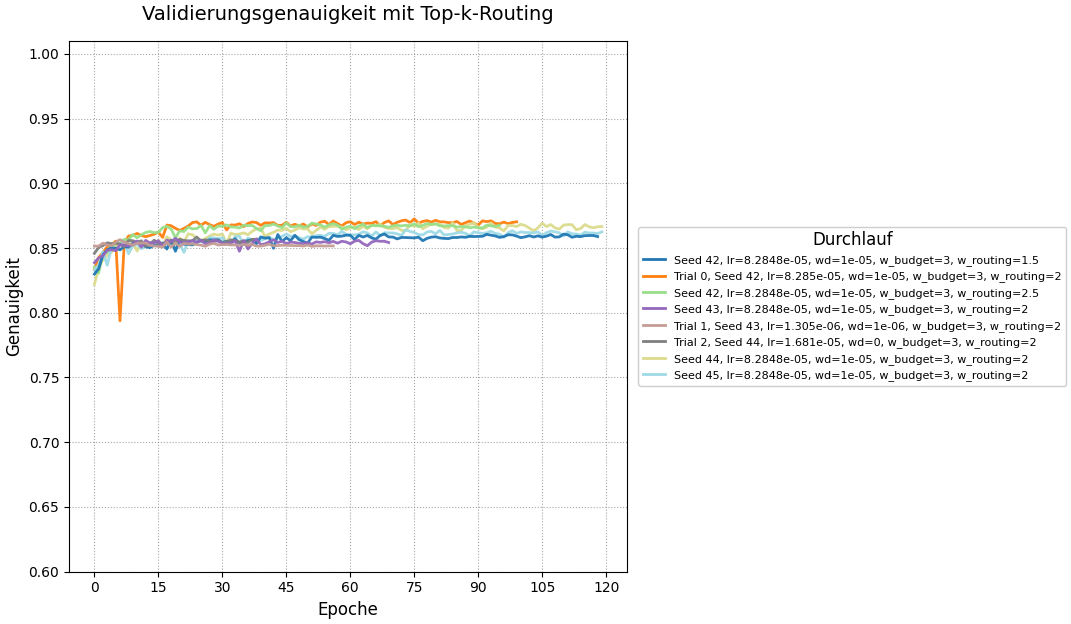

In [8]:
fig, ax = plt.subplots(figsize=(11, 6.5))
frame = tag_frame("val_topk/accuracy")
run_order_topk = beste_runs_nach_tag("val_topk/accuracy")

for run in run_order_topk:
    run_frame = frame.loc[frame["run"] == run]
    if run_frame.empty:
        continue
    ax.plot(
        run_frame["epoche"],
        run_frame["wert"],
        color=color_by_run[run],
        linewidth=2.0,
        alpha=0.95,
    )

style_axis(ax, ylabel="Genauigkeit", ylim=(0.6, 1.01))
ax.set_title("Validierungsgenauigkeit mit Top-k-Routing", pad=15)
durchlauf_legende(ax)
fig.tight_layout()
speichere_abbildung(fig, "routingloss_r2fix_reproduce_val_topk_accuracy")
plt.show()

## Upper-Bound-Verläufe

Gespeichert: plots/figures_routingloss_r2fix_reproduce/routingloss_r2fix_reproduce_val_upper_bounds.png


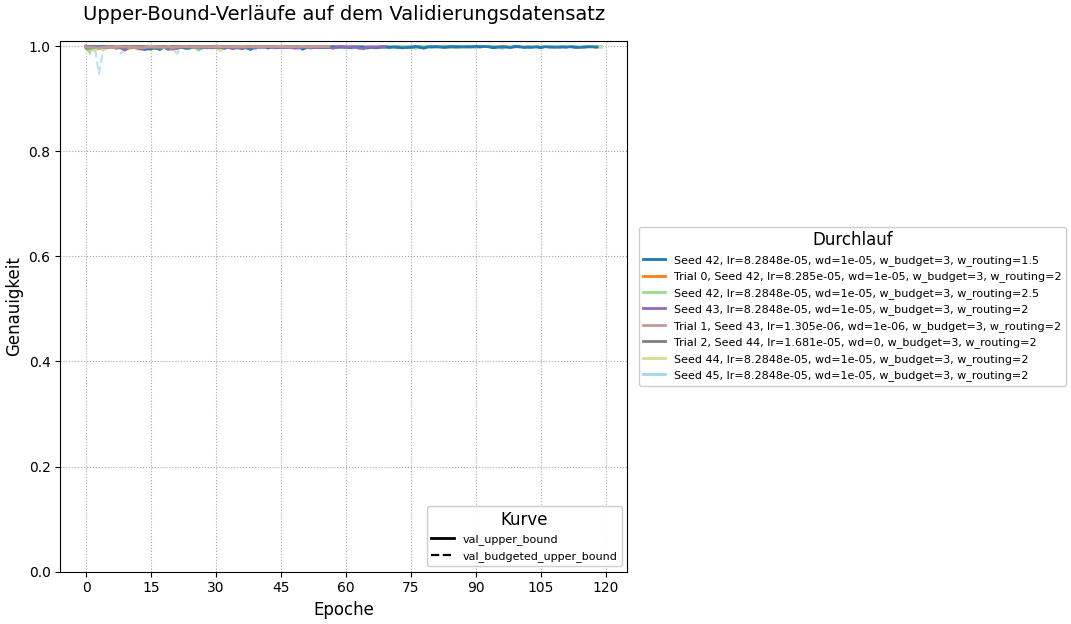

In [9]:
fig, ax = plt.subplots(figsize=(11, 6.5))
upper_specs = [
    ("val_upper_bound", "Upper Bound", "-"),
    ("val_budgeted_upper_bound", "Budgeted Upper Bound", "--"),
]
run_order_upper = beste_runs_nach_tag("val_upper_bound")

for run in run_order_upper:
    color = color_by_run[run]
    for tag, _, linestyle in upper_specs:
        frame = tag_frame(tag).loc[lambda df: df["run"] == run]
        if frame.empty:
            continue
        ax.plot(
            frame["epoche"],
            frame["wert"],
            color=color,
            linestyle=linestyle,
            linewidth=2.0 if linestyle == "-" else 1.6,
            alpha=0.95 if linestyle == "-" else 0.7,
        )

style_axis(ax, ylabel="Genauigkeit", ylim=(0.0, 1.01))
ax.set_title("Upper-Bound-Verläufe auf dem Validierungsdatensatz", pad=15)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=2.0, label="val_upper_bound"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.6, label="val_budgeted_upper_bound"),
]
first_legend = ax.legend(handles=style_handles, loc="lower right", title="Kurve", framealpha=0.95)
ax.add_artist(first_legend)
durchlauf_legende(ax)

fig.tight_layout()
speichere_abbildung(fig, "routingloss_r2fix_reproduce_val_upper_bounds")
plt.show()